In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

import pandas as pd
import numpy as np


In [2]:


A = np.array([[1, 2],
              [4, 6],
              [7, 1]])

B = np.array([[0, 0],
              [5, 5]])

# 1) reshape
A_exp = A[:, np.newaxis, :]
B_exp = B[np.newaxis, :, :]

print(A_exp.shape)  # (3,1,2)
print(B_exp.shape)  # (1,2,2)

# 2) difference
diff = A_exp - B_exp
print(diff.shape)

# 3) distance
dist = np.sqrt(np.sum(diff**2, axis=2))
print(np.round(dist, 2))

# 4) average distance
avg = dist.mean(axis=0)
print(avg)

(3, 1, 2)
(1, 2, 2)
(3, 2, 2)
[[2.24 5.  ]
 [7.21 1.41]
 [7.07 4.47]]
[5.50607945 3.62878317]


<h2>Warehouse B1 is closer on average because its mean distance (≈ 3.63) is smaller than that of B0 (≈ 5.51).</h2>

In [3]:


p = np.array([2, 1, -3])
q = np.array([4, -2, 1])

# 1) four methods
dot1 = sum(p[i]*q[i] for i in range(3))
dot2 = np.dot(p, q)
dot3 = np.sum(np.multiply(p, q))
dot4 = np.matmul(p, q)

print(dot1, dot2, dot3, dot4)

# 2) angle
norm_p = np.linalg.norm(p)
norm_q = np.linalg.norm(q)

cos_theta = dot2 / (norm_p * norm_q)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print(theta_rad, theta_deg)

3 3 3 3
1.3949275767021716 79.92346287144585


In [4]:
# 4) orthogonal vector
r = np.cross(p, q)
print(r)
print(np.dot(p, r))  # ≈ 0

[ -5 -14  -8]
0


In [5]:
u = np.array([3, -4])
v = np.array([-6, 8])

# 1) magnitudes
norm_u = np.linalg.norm(u)
norm_v = np.linalg.norm(v)
ratio = norm_v / norm_u

print(norm_u, norm_v, ratio)

# 2) unit vectors
u_unit = u / norm_u
v_unit = v / norm_v

print(u_unit, v_unit)

5.0 10.0 2.0
[ 0.6 -0.8] [-0.6  0.8]


In [6]:
# 3) parallel check
dot = np.dot(u, v)
print(dot == norm_u * norm_v * (-1))  

True


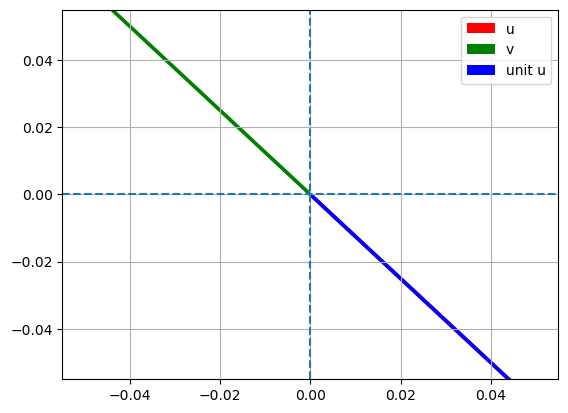

In [17]:
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')

plt.quiver(0,0,u[0],u[1],angles='xy',scale_units='xy',scale=1,label='u', color= 'r')
plt.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,label='v', color = 'g')
plt.quiver(0,0,u_unit[0],u_unit[1],angles='xy',scale_units='xy',scale=1,label='unit u', color = 'b')

plt.legend()
plt.grid()
plt.show()

In [8]:
df = sns.load_dataset('mpg')

# 1
print(df.shape)
print(df.head())

# 2
print(df.isnull().sum())

# 3
df_clean = df.dropna()
print(df_clean.shape)

# 4
print(df_clean.describe())

(398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
(392, 9)
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000

<p>The dataset has 398 rows and 9 columns. The 'horsepower' column contains 6 missing values.

After removing missing values, the dataset contains 392 rows.

The average mpg is approximately 23.45.</p>

In [9]:
# 1
filtered = df_clean[df_clean['mpg'] > 30]
print(len(filtered))

# 2
top5 = df_clean.sort_values(by='mpg', ascending=False)[['name','mpg','cylinders','origin']].head()
print(top5)

# 3
group = df_clean.groupby('origin')['mpg'].mean()
print(group)

83
                     name   mpg  cylinders  origin
322             mazda glc  46.6          4   japan
329   honda civic 1500 gl  44.6          4   japan
325  vw rabbit c (diesel)  44.3          4  europe
394             vw pickup  44.0          4  europe
326    vw dasher (diesel)  43.4          4  europe
origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64


<p>Cars from Japan have the highest average MPG, so they are the most fuel-efficient on average.</p>

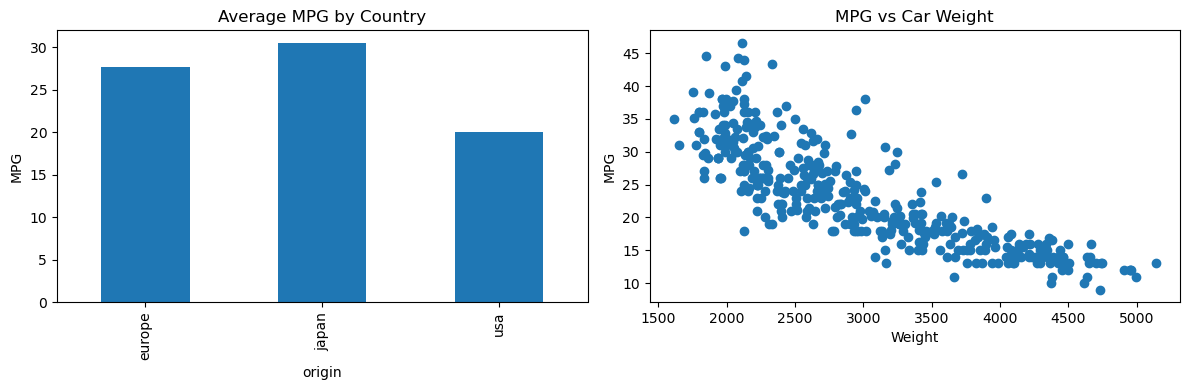

In [10]:
plt.figure(figsize=(12,4))

# left
plt.subplot(1,2,1)
df_clean.groupby('origin')['mpg'].mean().plot(kind='bar')
plt.title('Average MPG by Country')
plt.ylabel('MPG')

# right
plt.subplot(1,2,2)
plt.scatter(df_clean['weight'], df_clean['mpg'])
plt.title('MPG vs Car Weight')
plt.xlabel('Weight')
plt.ylabel('MPG')

plt.tight_layout()
plt.show()

<h2>As the weight of a car increases, its MPG generally decreases. This shows a negative relationship between weight and fuel efficiency.</h2>

In [11]:
data = load_wine()
print(data.feature_names)
print(data.target_names)
print(data.data.shape)

# 2
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.25, random_state=42
)

# 3
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(accuracy)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']
(178, 13)
0.7111111111111111


<h2>This is a classification problem because the model predicts discrete classes (wine types 0, 1, and 2).</h2>